# Preprocessing

Before the research questions are addressed, the survey and attribute data undergo a shared preprocessing stage. The aim is to prepare compact, non-redundant predictor sets for later analysis. Because Detmold and Turin are analysed as separate case cities—with ten streetscape points and independent respondent samples in each—the screening is applied **within city** rather than on the pooled twenty-point sample. The same statistical logic is used for both data sources: first remove uninformative predictors, then inspect pairwise redundancy.

The procedure comprises two steps, each split by data source:

1. **Uninformative-attribute screening** — attribute table (§1.1) and questionnaire data (§1.2)
2. **Multi-collinearity screening** — attribute table (§2.1) and questionnaire data (§2.2)

Each subsection is introduced below, followed by the corresponding tables and figures, and a results and discussion section. After §1, city-specific removal lists are applied to the working data before §2. Pairwise Spearman tables in §2 list **all** unique predictor pairs (sorted by |ρ|) and include a **Flagged Correlation** column: `True` when |ρ| exceeds the city-specific threshold (**0.7** for streetscape attributes in §2.1; **0.8** for questionnaire fields in §2.2). Streetscape attributes that pass variation screening in **both** cities form the shared working set for substantive collinearity drops before RQ2.


In [1]:
import matplotlib
matplotlib.use("Agg")

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

import config as cfg
from config import CITIES, FIGURES_DIR, TABLES_DIR
from utils import (
    all_physical_predictors,
    apply_plot_theme,
    attribute_quality_report_by_city,
    attribute_spearman_correlation,
    filter_attribute_dataframe,
    filter_attributes_by_city,
    filter_layers_by_columns,
    filter_survey_by_city,
    build_screened_attribute_tables_by_city,
    build_screened_questionnaire_columns_by_city,
    city_kept_items,
    city_variation_removals,
    format_city_variation_screening_table,
    format_collinearity_pairs_table,
    format_questionnaire_collinearity_pairs_table,
    format_questionnaire_screening_table,
    intersection_kept_items,
    load_analysis_data,
    pairwise_high_abs_rho_pairs,
    pairwise_spearman_rho_pairs,
    plot_attribute_correlation_matrix,
    questionnaire_quality_report_by_city,
    questionnaire_spearman_correlation,
    screened_questionnaire_columns_for_city,
    save_figure,
    save_table,
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

apply_plot_theme()
df_survey, df_attr_raw, attr_layers_sheet = load_analysis_data()


## 1. Uninformative-attribute screening

Predictors that barely vary cannot explain why comfort differs between streetscapes or respondent profiles. In multivariate work, **near-zero variance screening** is recommended before correlation or regression steps, because invariant or almost-invariant fields add noise without explanatory value (Zuur et al., 2010; Field, 2018). Place-comparison streetscape studies apply the same logic by retaining only descriptors that differ meaningfully between sites (Zhu et al., 2026; Urban et al., 2022).

The same three-rule logic is applied **within each city** (Detmold and Turin separately), but the rules differ slightly between the attribute table (§1.1) and questionnaire data (§1.2) because streetscape predictors are numeric compositions across ten image points whereas questionnaire fields are categorical respondent profiles.

**Attribute table (§1.1)**

1. **Constant** — fewer than two distinct values across the city's ten survey points.
2. **Near-absent** — for street-view pixel shares, non-zero at fewer than three of ten points (stricter than the pooled three-of-twenty rule; Zuur et al., 2010).
3. **Low normalized Shannon entropy** — \(H_\mathrm{norm} < 0.50\), removing attributes whose value distribution remains effectively uniform or single-level even when not strictly constant (Larkin et al., 2021).

**Questionnaire data (§1.2)**

1. **Constant** — a single response category only.
2. **Near-constant** — modal category accounts for at least 95% of valid answers (Field, 2018; *caret* near-zero-variance logic for factors).
3. **Low normalized Shannon entropy** — \(H_\mathrm{norm} < 0.50\), flagging categorical fields with too little response diversity to support within-city profile comparisons (Zuur et al., 2010).

Attributes or questionnaire variables removed in a city are excluded from that city's §2 collinearity screen and downstream modelling. Streetscape attributes must additionally pass in **both** cities to enter the shared attribute working set used for substantive collinearity drops before RQ2.


### 1.1 Attribute table

Each physical attribute is evaluated on the **ten survey points belonging to one city**. Remote-sensing indicators and street-view pixel shares pass through the constant, near-absent, and normalized Shannon entropy rules above. \(H_\mathrm{norm}\) measures how evenly values are distributed across the ten locations (0 = no diversity, 1 = maximum diversity for the observed levels; Larkin et al., 2021). The screening table reports the layer, attribute name, and all rules applied in Turin and Detmold (comma-separated when more than one rule triggers). Attributes removed in a city are excluded from that city's §2.1 collinearity screen; only names retained in **both** cities enter the shared attribute working set for substantive modelling drops.


In [2]:
attr_quality_city = attribute_quality_report_by_city(
    df_attr_raw,
    layers=attr_layers_sheet,
)
kept_attr = intersection_kept_items(attr_quality_city, item_col="attribute")
attr_layers_all = filter_layers_by_columns(attr_layers_sheet, kept_attr)
predictors = all_physical_predictors(attr_layers_all)

attr_var_table = format_city_variation_screening_table(attr_quality_city)
save_table("preprocessing_attribute_variation_screening_by_city", attr_var_table)
display(attr_var_table)


,Layer,Attribute,Applied Rule to Turin,Applied rule to Detmold
0,Layer 1 — RS / GIS,Albedo,Kept,Kept
1,Layer 1 — RS / GIS,LST(°C),Kept,Kept
2,Layer 1 — RS / GIS,MNDWI,Kept,Kept
3,Layer 1 — RS / GIS,NDVI,Kept,Kept
4,Layer 3a — SVI Pixel %,Bicycle (%),Kept,Kept
5,Layer 3a — SVI Pixel %,Building (%),Kept,Kept
6,Layer 3a — SVI Pixel %,Bus (%),"Constant, Near absent, Low entropy","Near absent, Low entropy"
7,Layer 3a — SVI Pixel %,Car (%),Kept,Kept
8,Layer 3a — SVI Pixel %,Fence (%),Kept,Kept
9,Layer 3a — SVI Pixel %,Motorcycle (%),"Near absent, Low entropy","Constant, Near absent, Low entropy"


#### Results and discussion — attribute variation

Across both cities, twenty-three streetscape attributes were screened on ten points each. Under the stricter near-absent rule (≥ 3 non-zero points), Detmold and Turin each retain **seventeen** attributes; the city intersection is therefore also **seventeen** for §2.1. Six names fail in at least one city: train (constant in both), and five rare street-view classes—truck, bus, motorcycle, rider, and traffic light—flagged as constant, near-absent, and/or low entropy depending on city. Traffic light (%) now fails in **both** cities once the near-absent threshold is raised from two to three non-zero points.

With the tighter \(H_\mathrm{norm} < 0.50\) floor, no additional *kept* attribute is removed beyond the constant and near-absent rules—the surviving predictors still carry sufficient compositional diversity across the ten street sections (minimum \(H_\mathrm{norm} \approx 0.68\) among retained names). The entropy screen therefore remains a confirmatory check at this sample size (Larkin et al., 2021; Zuur et al., 2010).


### 1.2 Questionnaire data

Respondent-profile fields are screened on the **Detmold and Turin questionnaire samples separately** (n ≈ 116 and 119). Categorical answers pass through the constant, near-constant (≥ 95% modal category), and \(H_\mathrm{norm} < 0.50\) rules described in §1. Fields removed here are withheld from that city's collinearity screen (§2.2) and from the corresponding RQ2 model, while other cities may retain them when their response distributions differ (Chen et al., 2022).


In [3]:
q_quality_city = questionnaire_quality_report_by_city(df_survey)

q_var_table = format_questionnaire_screening_table(q_quality_city)
save_table("preprocessing_questionnaire_variation_screening_by_city", q_var_table)
display(q_var_table)


,Group,Attribute,Applied Rule to Turin,Applied rule to Detmold
0,Demographics,Gender,Kept,Kept
1,Demographics,Age,Kept,Kept
2,Demographics,Birthplace,Kept,Kept
3,Demographics,Education,Kept,Kept
4,Demographics,Occupation,Kept,Kept
5,Demographics,Daily activity,Kept,Kept
6,Demographics,City relationship,Kept,Kept
7,Demographics,Time in city,Kept,Kept
8,Summer & adaptation,Summer visit,Low entropy,Low entropy
9,Summer & adaptation,Summer description,Kept,Kept


#### Results and discussion — questionnaire variation

The near-constant rule (≥ 95% modal share) and entropy floor (\(H_\mathrm{norm} < 0.50\)) remove only **summer visit** in both cities. Its modal yes-share (≈92% in Detmold, ≈94% in Turin) remains below the 95% near-constant threshold, but \(H_\mathrm{norm}\) is too low for within-city profile comparisons, so the field is dropped on low-entropy grounds alone.

All other questionnaire fields—including city relationship, gender, occupation, daily activity, and transport modes—pass both screens in each city. Detmold and Turin therefore each contribute **fifteen** questionnaire fields to §2.2.


### City-specific removals (before §2)

After §1, each city’s datasets drop the predictors listed below (a — Turin; b — Detmold, with attribute-table and questionnaire sub-lists). Those names are **removed from the working data** before any §2 collinearity analysis—the screened attribute tables and questionnaire column lists used in §2 contain only the survivors.

In [4]:
def _print_variation_removals(quality, *, item_col: str, city: str) -> None:
    removed = quality.loc[(quality["city"] == city) & ~quality["kept"]].sort_values(item_col)
    if removed.empty:
        print("    (none)")
        return
    for _, row in removed.iterrows():
        print(f"    • {row[item_col]} ({row['applied_rule']})")


city_outline = [("a", "Turin"), ("b", "Detmold")]

for label, city in city_outline:
    print(f"{label} — {city}")
    print(f"  {label}-1 — Attribute table")
    _print_variation_removals(attr_quality_city, item_col="attribute", city=city)
    print(f"  {label}-2 — Questionnaire")
    _print_variation_removals(q_quality_city, item_col="variable", city=city)
    print()

df_attr_screened_by_city = build_screened_attribute_tables_by_city(
    df_attr_raw,
    attr_quality_city,
    attr_layers_sheet,
)
questionnaire_cols_screened_by_city = build_screened_questionnaire_columns_by_city(
    q_quality_city,
)

print("§1 removals applied — inputs for §2:")
for label, city in city_outline:
    n_attr_removed = len(city_variation_removals(attr_quality_city, item_col="attribute")[city])
    n_q_removed = len(city_variation_removals(q_quality_city, item_col="variable")[city])
    print(
        f"  {label} — {city}: "
        f"{len(df_attr_screened_by_city[city])} attributes, "
        f"{len(questionnaire_cols_screened_by_city[city])} questionnaire fields "
        f"({n_attr_removed} attribute + {n_q_removed} questionnaire removals excluded)"
    )

a — Turin
  a-1 — Attribute table
    • Bus (%) (Constant, Near absent, Low entropy)
    • Motorcycle (%) (Near absent, Low entropy)
    • Rider (%) (Near absent, Low entropy)
    • Traffic light (%) (Constant, Near absent, Low entropy)
    • Train (%) (Constant, Near absent, Low entropy)
    • Truck (%) (Constant, Near absent, Low entropy)
  a-2 — Questionnaire
    • summer_visit (Low entropy)

b — Detmold
  b-1 — Attribute table
    • Bus (%) (Near absent, Low entropy)
    • Motorcycle (%) (Constant, Near absent, Low entropy)
    • Rider (%) (Near absent, Low entropy)
    • Traffic light (%) (Near absent)
    • Train (%) (Constant, Near absent, Low entropy)
    • Truck (%) (Near absent, Low entropy)
  b-2 — Questionnaire
    • summer_visit (Low entropy)

§1 removals applied — inputs for §2:
  a — Turin: 10 attributes, 15 questionnaire fields (6 attribute + 1 questionnaire removals excluded)
  b — Detmold: 10 attributes, 15 questionnaire fields (6 attribute + 1 questionnaire removals 

## 2. Multi-collinearity screening

Streetscape and questionnaire datasets often contain multiple measures of the same underlying quality—for example, vegetation visible in a street-view image and a vegetation index from remote sensing, or age and education in a socio-demographic block. When predictors are highly correlated, regression coefficients become unstable and physical interpretation is obscured (Dormann et al., 2013; Graham, 2003). **Pairwise correlation screening** remains the most widely used pre-modelling diagnostic; Dormann et al. (2013) show that simple threshold-based exclusion performs as well as more elaborate remedies in many applied settings, with |r| between 0.4 and 0.85 chosen according to field, sample size, and goal. Zuur et al. (2010) likewise recommend inspecting the correlation structure visually and numerically before fixing a rule.

**Spearman's ρ** is used throughout because street-view shares are bounded compositions and questionnaire fields are ordinal or nominal categories encoded for screening (Zhu et al., 2026; Yang et al., 2025). For each city separately, the predictors listed in §1 as removed for that city are **dropped first**; pairwise ρ is then computed only among the survivors. Companion tables report every unique pair, sorted by |ρ|. **Flagged Correlation** uses |ρ| > **0.7** for streetscape attributes (§2.1) and |ρ| > **0.8** for questionnaire fields (§2.2). The stricter questionnaire threshold follows Dormann et al. (2013), who recommend choosing cut-offs within roughly 0.4–0.85 according to how tightly predictors are expected to overlap, and Hair et al. (2019), who treat |r| ≳ 0.8 as the usual multicollinearity concern in survey-based regression. Streetscape layers contain many near-duplicate measures of the same physical scene (e.g. NDVI vs vegetation share), whereas socio-demographic fields can correlate moderately without measuring the same construct—so a higher bar reduces unnecessary drops. Pairs involving a street-view pixel share list the `(%)` variable first. Flagged pairs are reviewed for substantive overlap before any variable is dropped from the modelling set.


### 2.1 Attribute table

For each city, the attribute table is first reduced to predictors that passed §1.1 variation screening **in that city** (the complements of the a-1 / b-1 removal lists). Pairwise Spearman ρ is computed on that city's ten points and visualised as a layer-ordered heatmap. The companion table lists all \(\binom{n}{2}\) unique pairs among the city's \(n\) surviving attributes, sorted by |ρ| descending; **Flagged Correlation** is `True` when |ρ| > 0.7. Flagged pairs are then reviewed **iteratively** city by city (see below): after each substantive drop, the remaining flagged set is re-inspected until no |ρ| > 0.7 links remain among survivors or further removal would sacrifice interpretable streetscape structure (Dormann et al., 2013; Graham, 2003).


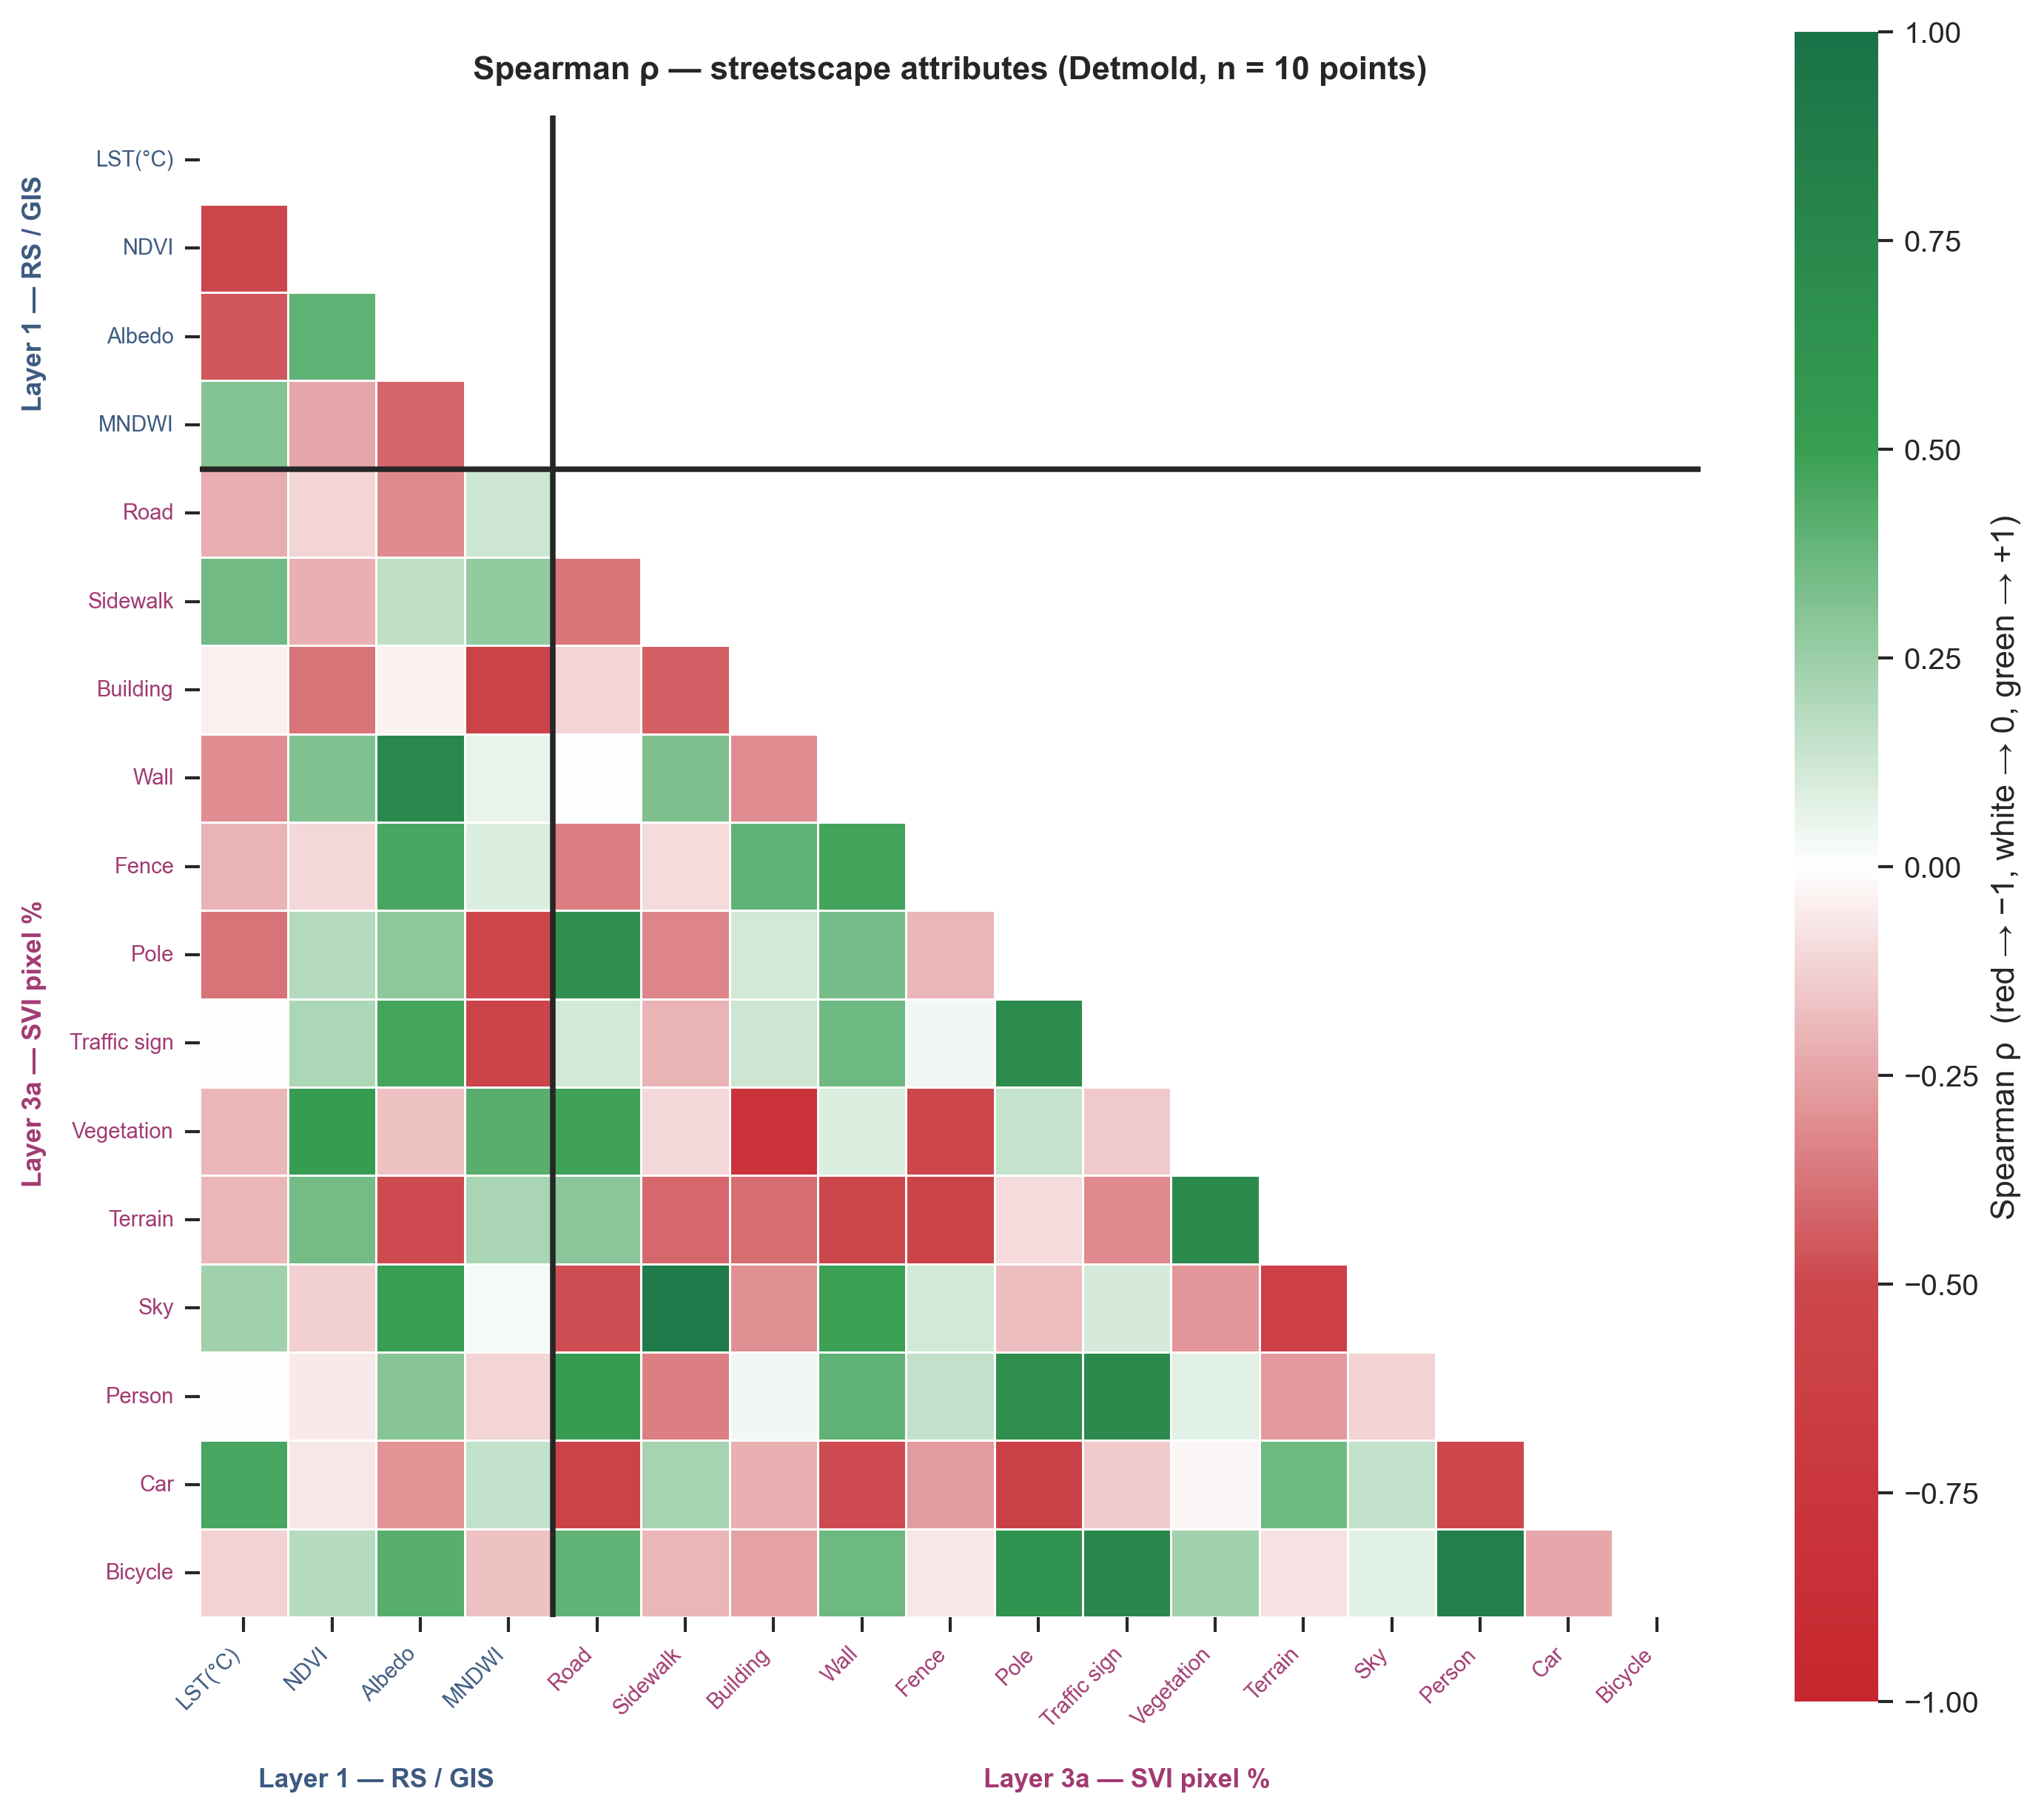

,City,Attribute,Partner Attribute,Spearman ρ,|ρ|,Flagged Correlation
0,Detmold,Sidewalk (%),Sky (%),0.903,0.903,True
1,Detmold,Bicycle (%),Person (%),0.840,0.840,True
2,Detmold,Building (%),Vegetation (%),-0.806,0.806,True
3,Detmold,Bicycle (%),Traffic sign (%),0.753,0.753,True
4,Detmold,Wall (%),Albedo,0.736,0.736,True
5,Detmold,Terrain (%),Vegetation (%),0.723,0.723,True
6,Detmold,Person (%),Traffic sign (%),0.713,0.713,True
7,Detmold,Pole (%),Traffic sign (%),0.709,0.709,True
8,Detmold,Person (%),Pole (%),0.684,0.684,False
9,Detmold,Pole (%),Road (%),0.669,0.669,False


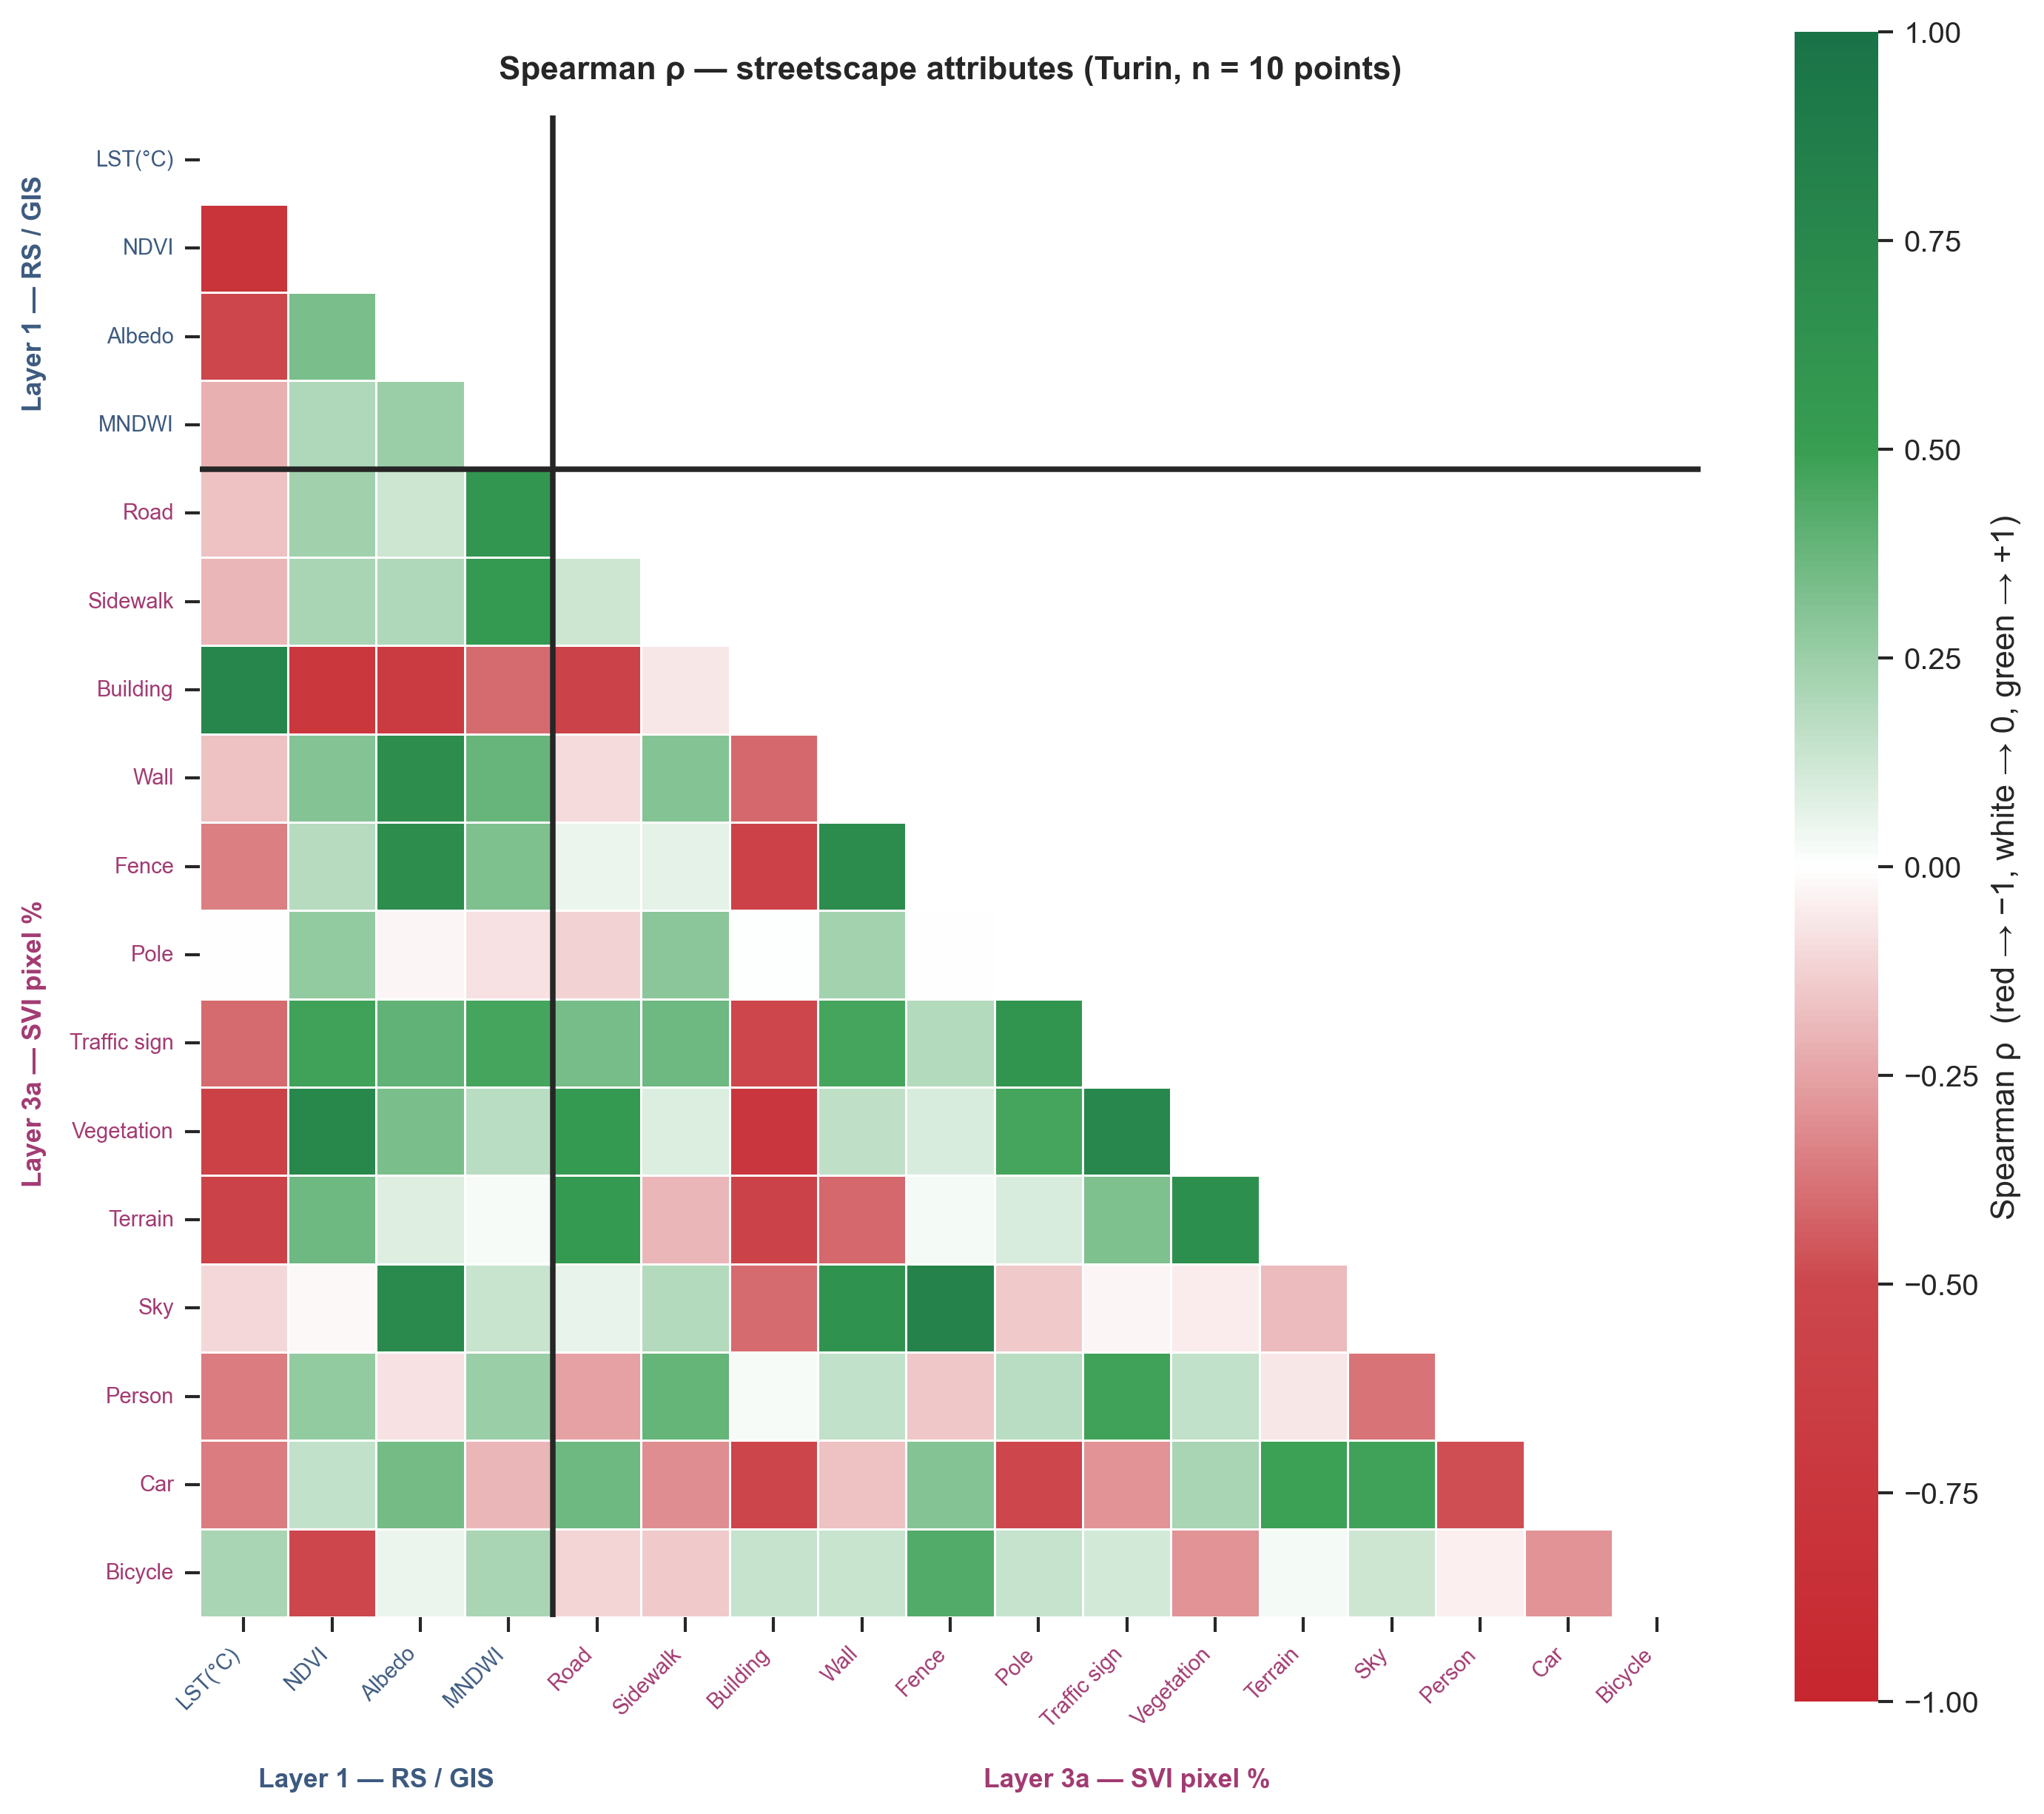

,City,Attribute,Partner Attribute,Spearman ρ,|ρ|,Flagged Correlation
0,Turin,Fence (%),Sky (%),0.813,0.813,True
1,Turin,LST(°C),NDVI,-0.782,0.782,True
2,Turin,Building (%),LST(°C),0.770,0.770,True
3,Turin,Traffic sign (%),Vegetation (%),0.763,0.763,True
4,Turin,Building (%),Vegetation (%),-0.758,0.758,True
5,Turin,Vegetation (%),NDVI,0.758,0.758,True
6,Turin,Building (%),NDVI,-0.733,0.733,True
7,Turin,Sky (%),Albedo,0.729,0.729,True
8,Turin,Fence (%),Wall (%),0.706,0.706,True
9,Turin,Fence (%),Albedo,0.696,0.696,False


In [5]:
pairs_by_city = {}

for city in CITIES:
    df_city_attr = df_attr_screened_by_city[city]
    city_predictors = list(df_city_attr.columns)
    city_layers = filter_layers_by_columns(attr_layers_sheet, set(city_predictors))

    corr = attribute_spearman_correlation(df_city_attr, city_predictors)
    save_table(
        f"preprocessing_attribute_spearman_correlation_{city.lower()}",
        corr.reset_index(),
    )

    fig_matrix = plot_attribute_correlation_matrix(
        corr,
        city_layers,
        title=f"Spearman ρ — streetscape attributes ({city}, n = 10 points)",
    )
    slug = city.lower()
    save_figure(fig_matrix, f"fig_preprocessing_attribute_spearman_correlation_{slug}")
    display(Image(filename=FIGURES_DIR / f"fig_preprocessing_attribute_spearman_correlation_{slug}.png", width=950))

    pairs_all = pairwise_spearman_rho_pairs(corr, city_predictors)
    pairs_by_city[city] = pairwise_high_abs_rho_pairs(corr, city_predictors)
    pairs_table = format_collinearity_pairs_table(pairs_all)
    pairs_table.insert(0, "City", city)
    save_table(f"preprocessing_collinearity_pairs_{slug}", pairs_table)
    with pd.option_context("display.max_rows", None):
        display(pairs_table)


#### Results and discussion — attribute collinearity

City-specific matrices reveal similar but not identical redundancy structures. Among 136 unique pairs per city (seventeen surviving attributes), **eight** pairs in Detmold and **nine** in Turin exceed |ρ| = 0.7 and are flagged in the companion table. In Detmold, the strongest links involve sidewalk–sky (ρ ≈ 0.90), bicycle–person (ρ ≈ 0.84), and building–vegetation share (ρ ≈ 0.81). In Turin, associations concentrate among fence–sky (ρ ≈ 0.81), LST–NDVI (ρ ≈ 0.78), and building–LST (ρ ≈ 0.77)—patterns reported in comparable streetscape perception work (Larkin et al., 2021; Zhu et al., 2026).

Because several attributes sit at the centre of multiple flagged pairs, a single threshold pass is insufficient: removing one redundant measure often leaves others still above |ρ| = 0.7. The iterative review below documents how flagged pairs were cleared in each city and which names are excluded from the shared RQ2 attribute set.


#### Iterative review of flagged pairs (|ρ| > 0.7)

**Why iterate?** Pairwise screening identifies *pairs*, but collinearity is a *network* property: one attribute—especially remote-sensing indices or dominant morphological shares—can appear in several flagged links at once (Dormann et al., 2013). Dropping a single member of each pair in one pass may leave hub attributes that still exceed |ρ| = 0.7 with multiple partners. An iterative procedure—flag pairs, remove the most conceptually duplicated or multiply connected measure, then re-inspect the surviving flagged set—mirrors cascade-style filters used when correlations are not independent (Graham, 2003; UK Urban Analytics Platform, n.d.). At each step we prefer removing the measure that (i) participates in the largest number of remaining flagged pairs, and (ii) overlaps most clearly with a retained indicator of the same streetscape quality (e.g. keep **Vegetation (%)** and **LST(°C)** rather than **NDVI** when greenness and surface temperature are already represented).

The review below starts from the **Flagged Correlation** rows in each city's §2.1 table. After every removal round, only pairs that would still exceed |ρ| = 0.7 among *remaining* attributes are listed. Both cities converge on the same five substantive drops for the shared modelling set.

---

**Turin** — initial flagged pairs (nine):

| Attribute | Partner attribute |
|-----------|-------------------|
| Fence (%) | Sky (%) |
| LST(°C) | NDVI |
| Building (%) | LST(°C) |
| Traffic sign (%) | Vegetation (%) |
| Building (%) | Vegetation (%) |
| Vegetation (%) | NDVI |
| Building (%) | NDVI |
| Sky (%) | Albedo |
| Fence (%) | Wall (%) |

*Round 1 — remove **NDVI** and **Building (%)**.* NDVI duplicates the greenness signal already carried by **Vegetation (%)**; **Building (%)** is entangled with LST, vegetation share, and NDVI. Remaining flagged pairs:

| Attribute | Partner attribute |
|-----------|-------------------|
| Fence (%) | Sky (%) |
| Traffic sign (%) | Vegetation (%) |
| Sky (%) | Albedo |
| Fence (%) | Wall (%) |

*Round 2 — remove **Fence (%)**.* Fence share is strongly linked to both sky and wall openness; retaining **Wall (%)** and **Sky (%)** preserves enclosure and openness separately. Remaining flagged pairs:

| Attribute | Partner attribute |
|-----------|-------------------|
| Traffic sign (%) | Vegetation (%) |
| Sky (%) | Albedo |

*Round 3 — remove **Traffic sign (%)** and **Albedo**.* **Traffic sign (%)** overlaps the vegetation / street-furniture composition already described by **Vegetation (%)**; **Albedo** duplicates the openness signal in **Sky (%)** (Yang et al., 2025). No flagged pairs remain among Turin survivors.

---

**Detmold** — initial flagged pairs (eight):

| Attribute | Partner attribute |
|-----------|-------------------|
| Sidewalk (%) | Sky (%) |
| Bicycle (%) | Person (%) |
| Building (%) | Vegetation (%) |
| Bicycle (%) | Traffic sign (%) |
| Wall (%) | Albedo |
| Terrain (%) | Vegetation (%) |
| Person (%) | Traffic sign (%) |
| Pole (%) | Traffic sign (%) |

*Round 1 — remove **NDVI**.* NDVI is dropped from the **shared** modelling set because it is redundant with **Vegetation (%)** and was a primary hub in Turin; keeping one greenness index avoids asymmetric predictor sets across cities. Remaining flagged pairs in Detmold:

| Attribute | Partner attribute |
|-----------|-------------------|
| Sidewalk (%) | Sky (%) |
| Bicycle (%) | Person (%) |
| Building (%) | Vegetation (%) |
| Bicycle (%) | Traffic sign (%) |
| Wall (%) | Albedo |
| Terrain (%) | Vegetation (%) |
| Person (%) | Traffic sign (%) |
| Pole (%) | Traffic sign (%) |

*Round 2 — remove **Fence (%)** and **Building (%)**.* **Building (%)** clears the building–vegetation block; **Fence (%)** is removed for cross-city consistency with Turin. Remaining flagged pairs:

| Attribute | Partner attribute |
|-----------|-------------------|
| Traffic sign (%) | Vegetation (%) |
| Sky (%) | Albedo |

*Round 3 — remove **Traffic sign (%)** and **Albedo**.* Same substantive reasoning as Turin: retain **Vegetation (%)** and **Sky (%)** as the interpretable streetscape descriptors. No flagged pairs remain among Detmold survivors.

---

**Shared modelling set (both cities).** Five attributes are excluded after iterative review:

| Removed | Rationale |
|---------|-----------|
| **NDVI** | Redundant with **Vegetation (%)** (continuous vs. image-based greenness) |
| **Building (%)** | Hub linking LST, vegetation share, and morphology |
| **Fence (%)** | Strongly collinear with **Sky (%)** and **Wall (%)** |
| **Traffic sign (%)** | Collinear with **Vegetation (%)** and other street-furniture shares |
| **Albedo** | Collinear with **Sky (%)** / openness (Yang et al., 2025) |

**Twelve** streetscape predictors enter RQ2. The screen does not claim statistical independence among all survivors; it clears the |ρ| > 0.7 network while keeping one interpretable indicator per streetscape quality where possible (Dormann et al., 2013; Zhu et al., 2026).

### 2.2 Questionnaire data

The same pairwise Spearman procedure is applied to questionnaire covariates **within each city**, using only fields that passed §1.2 variation screening in that city (the complements of the a-2 / b-2 removal lists). Categories are ordinally encoded where a natural order exists (age bands, education levels, transport-frequency scales); otherwise, categories are label-encoded solely for the correlation screen (Hair et al., 2019). The companion table lists all unique pairs among the city's surviving fields, sorted by |ρ|, with **Flagged Correlation** set to `True` when |ρ| > **0.8**—a stricter cut-off than §2.1 because questionnaire correlations in this sample remain below the level typical of duplicate streetscape measures, and because moderate socio-demographic association (e.g. age with education or occupation) does not by itself imply redundant predictors (Dormann et al., 2013; Hair et al., 2019; Chen et al., 2022).


In [6]:
q_pairs_by_city = {}

for city in CITIES:
    q_cols = questionnaire_cols_screened_by_city[city]
    sub = filter_survey_by_city(df_survey, city)
    q_corr = questionnaire_spearman_correlation(sub, q_cols)
    q_pairs_all = pairwise_spearman_rho_pairs(q_corr, q_cols)
    q_pairs_by_city[city] = pairwise_high_abs_rho_pairs(q_corr, q_cols)

    q_pairs_table = format_questionnaire_collinearity_pairs_table(q_pairs_all)
    q_pairs_table.insert(0, "City", city)
    slug = city.lower()
    save_table(f"preprocessing_questionnaire_collinearity_pairs_{slug}", q_pairs_table)
    with pd.option_context("display.max_rows", None):
        display(q_pairs_table)


,City,Variable,Partner variable,Spearman ρ,|ρ|,Flagged Correlation
0,Detmold,Age,Education,0.750,0.750,False
1,Detmold,Age,Occupation,-0.654,0.654,False
2,Detmold,Education,Occupation,-0.626,0.626,False
3,Detmold,Occupation,Time in city,-0.421,0.421,False
4,Detmold,City relationship,Transport (walking),-0.383,0.383,False
5,Detmold,Age,Time in city,0.344,0.344,False
6,Detmold,City relationship,Transport (car),0.340,0.340,False
7,Detmold,Time in city,Transport (car),0.333,0.333,False
8,Detmold,Transport (car),Transport (public),-0.328,0.328,False
9,Detmold,Transport (car),Transport (walking),-0.322,0.322,False


,City,Variable,Partner variable,Spearman ρ,|ρ|,Flagged Correlation
0,Turin,Heat adaptation,Summer description,-0.438,0.438,False
1,Turin,Age,Occupation,-0.401,0.401,False
2,Turin,Birthplace,Time in city,-0.378,0.378,False
3,Turin,Time in city,Transport (car),0.370,0.370,False
4,Turin,Occupation,Time in city,-0.365,0.365,False
5,Turin,Transport (car),Transport (public),-0.353,0.353,False
6,Turin,Occupation,Transport (public),0.344,0.344,False
7,Turin,Age,Transport (car),0.343,0.343,False
8,Turin,Age,Time in city,0.323,0.323,False
9,Turin,Age,Transport (public),-0.318,0.318,False


#### Results and discussion — questionnaire collinearity

Among 105 unique pairs per city (fifteen surviving fields), **no pair** exceeds |ρ| = 0.8 in either Detmold or Turin. The strongest associations are **age–education** in Detmold (ρ ≈ 0.75), **age–occupation** in Detmold (ρ ≈ −0.65), and **heat adaptation–summer description** in Turin (ρ ≈ −0.44). These values sit in the range where survey-based outdoor-comfort work often retains both predictors rather than treating them as duplicate measures (Chen et al., 2022; Hair et al., 2019). With the 0.8 flag threshold, **no questionnaire field is dropped** after collinearity review.

Detmold and Turin each contribute **fifteen** questionnaire fields to RQ1 and RQ2.


In [7]:
predictors_model = [
    p for p in predictors if p not in cfg.COLLINEARITY_PAIRWISE_MANUAL_DROPS
]
attr_layers_model = filter_layers_by_columns(attr_layers_all, set(predictors_model))

questionnaire_model_cols = {
    city: screened_questionnaire_columns_for_city(
        city,
        variation_quality=q_quality_city,
    )
    for city in CITIES
}


def _label_questionnaire_field(name: str) -> str:
    return cfg.QUESTIONNAIRE_VARIABLE_LABELS.get(name, name.replace("_", " ").title())


for label, city in city_outline:
    print(f"{label} — {city}")
    print(f"  {label}-1 — Attribute table ({len(predictors_model)})")
    for name in predictors_model:
        print(f"    • {name}")
    q_cols = questionnaire_model_cols[city]
    print(f"  {label}-2 — Questionnaire ({len(q_cols)})")
    for name in q_cols:
        print(f"    • {_label_questionnaire_field(name)}")
    print()


a — Turin
  a-1 — Attribute table (12)
    • LST(°C)
    • MNDWI
    • Road (%)
    • Sidewalk (%)
    • Wall (%)
    • Pole (%)
    • Vegetation (%)
    • Terrain (%)
    • Sky (%)
    • Person (%)
    • Car (%)
    • Bicycle (%)
  a-2 — Questionnaire (15)
    • Age
    • Birthplace
    • City relationship
    • Daily activity
    • Education
    • Gender
    • Heat adaptation
    • Modify routes for heat
    • Occupation
    • Summer description
    • Time in city
    • Transport (car)
    • Transport (cycling)
    • Transport (public)
    • Transport (walking)

b — Detmold
  b-1 — Attribute table (12)
    • LST(°C)
    • MNDWI
    • Road (%)
    • Sidewalk (%)
    • Wall (%)
    • Pole (%)
    • Vegetation (%)
    • Terrain (%)
    • Sky (%)
    • Person (%)
    • Car (%)
    • Bicycle (%)
  b-2 — Questionnaire (15)
    • Age
    • Birthplace
    • City relationship
    • Daily activity
    • Education
    • Gender
    • Heat adaptation
    • Modify routes for heat
    • Occupation


## References

Buildings (2024). Street spatial form and thermal comfort study — Pearson |r| screening and VIF. *Buildings*, *14*(10), 3253. https://doi.org/10.3390/buildings14103253

Chen, L., Kántor, N., & Nikolopoulou, M. (2022). Meta-analysis of outdoor thermal comfort surveys in different European cities using the RUROS database: The role of background climate and gender. *Energy and Buildings*, *256*, 111757. https://doi.org/10.1016/j.enbuild.2021.111757

Dormann, C. F., Elith, J., Bacher, S., Buchmann, C., Carl, G., Carré, G., … Lautenbach, S. (2013). Collinearity: A review of methods to deal with it and a simulation study of their performance. *Ecography*, *36*(1), 27–46. https://doi.org/10.1111/j.1600-0587.2012.07348.x

Field, A. (2018). *Discovering statistics using R and RStudio* (2nd ed.). Sage.

Graham, M. H. (2003). Confronting multicollinearity in ecological multiple regression. *Ecology*, *84*(11), 2809–2815. https://doi.org/10.1890/03-3117

Hair, J. F., Black, W. C., & Babin, B. J. (2019). *Multivariate data analysis* (8th ed.). Cengage.

Larkin, A., Gu, X., Chen, L., & Hystad, P. (2021). Predicting perceptions of the built environment using GIS, satellite and street view image approaches. *Landscape and Urban Planning*, *216*, 104257. https://doi.org/10.1016/j.landurbplan.2021.104257

Nikolopoulou, M., & Steemers, K. (2003). Thermal comfort and psychological adaptation as a guide for designing urban spaces. *Energy and Buildings*, *35*(1), 95–101. https://doi.org/10.1016/S0378-7788(02)00084-1

UK Urban Analytics Platform (n.d.). Filter collinear explanatory variables (Appendix G). https://urban-analytics-technology-platform.github.io/demoland-project/code/02_models/02_collinearity_filter.html

Urban, J., Novotný, J., Pikl, M., & Zemek, F. (2022). Using Google Street View photographs to assess long-term outdoor thermal perception and thermal comfort in the urban environment during heatwaves. *Frontiers in Environmental Science*, *10*, 878341. https://doi.org/10.3389/fenvs.2022.878341

Yang, S., Chong, A., Liu, P., & Biljecki, F. (2025). Thermal comfort in sight: Thermal affordance and its visual assessment for sustainable streetscape design. *Building and Environment*, *271*, 112569. https://doi.org/10.1016/j.buildenv.2025.112569

Zhu, L., Samuelson, H. W., Biljecki, F., Tan, C. L., Wong, N. H., & Ang, Y. Q. (2026). Visual determinants of outdoor thermal comfort: Integrating explainable AI and perceptual assessments. *Building and Environment*, *293*, 114322. https://doi.org/10.1016/j.buildenv.2026.114322

Zuur, A. F., Ieno, E. N., & Elphick, C. S. (2010). A protocol for data exploration to avoid common statistical problems. *Methods in Ecology and Evolution*, *1*(1), 3–14. https://doi.org/10.1111/j.2041-210X.2009.00001.x
